# Credit Scoring Model: Predicting Creditworthiness

Objective: Predict an individual's creditworthiness (good credit risk vs bad credit risk) using past financial data.

Approach:
- Feature engineering from raw financial history (income, debt, payment behaviour, utilization).
- Classification with Logistic Regression, Decision Tree, and Random Forest.
- Model evaluation using Accuracy, Precision, Recall, F1-Score, and ROC-AUC.

Note on the dataset: this notebook generates a synthetic but realistic financial dataset (income, debts, payment history, credit utilization, etc.) so the full pipeline can be demonstrated end to end. The same pipeline works unchanged on a real dataset such as the UCI German Credit Data or a bank's internal loan-history table -- only the data-loading cell would need to change.

## 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, roc_curve,
                              confusion_matrix, ConfusionMatrixDisplay,
                              classification_report)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (7, 5)
np.random.seed(42)

## 2. Dataset

Simulating a loan-applicant dataset with 3,000 records. Each row represents one applicant, with financial history features and a target label `creditworthy` (1 = good credit risk, 0 = bad credit risk).

Features included:
- age, annual_income, employment_length_years
- existing_debt, loan_amount_requested, savings_balance
- num_credit_lines, num_late_payments_2yrs, previous_defaults
- credit_utilization_ratio, num_dependents
- home_ownership, loan_purpose (categorical)

In [2]:
n = 3000

age = np.random.randint(18, 70, n)
annual_income = np.random.lognormal(mean=10.5, sigma=0.5, size=n)
employment_length_years = np.clip(np.random.normal(loc=age - 22, scale=5, size=n), 0, 45).astype(int)
employment_length_years = np.minimum(employment_length_years, age - 18)
existing_debt = np.random.lognormal(mean=8.5, sigma=1.0, size=n)
loan_amount_requested = np.random.lognormal(mean=9.0, sigma=0.7, size=n)
num_credit_lines = np.random.poisson(4, n) + 1
num_late_payments_2yrs = np.random.poisson(1.2, n)
credit_utilization_ratio = np.clip(np.random.beta(2, 5, n), 0, 1)
previous_defaults = np.random.binomial(1, 0.12, n)
savings_balance = np.random.lognormal(mean=7.5, sigma=1.2, size=n)
num_dependents = np.random.poisson(1, n)
home_ownership = np.random.choice(["rent", "own", "mortgage"], size=n, p=[0.40, 0.25, 0.35])
loan_purpose = np.random.choice(
    ["car", "education", "business", "medical", "home_improvement", "other"], size=n
)

df = pd.DataFrame({
    "age": age,
    "annual_income": annual_income,
    "employment_length_years": employment_length_years,
    "existing_debt": existing_debt,
    "loan_amount_requested": loan_amount_requested,
    "num_credit_lines": num_credit_lines,
    "num_late_payments_2yrs": num_late_payments_2yrs,
    "credit_utilization_ratio": credit_utilization_ratio,
    "previous_defaults": previous_defaults,
    "savings_balance": savings_balance,
    "num_dependents": num_dependents,
    "home_ownership": home_ownership,
    "loan_purpose": loan_purpose,
})

df.head()

,age,annual_income,employment_length_years,existing_debt,loan_amount_requested,num_credit_lines,num_late_payments_2yrs,credit_utilization_ratio,previous_defaults,savings_balance,num_dependents,home_ownership,loan_purpose
0,56,55203.484302,37,15709.292642,4438.723750,9,0,0.211347,0,1229.473583,0,mortgage,business
1,69,24177.490193,45,10746.901617,20124.875871,11,2,0.115980,0,939.986340,1,mortgage,home_improvement
2,46,66627.035918,28,4529.148845,8317.407244,2,0,0.197780,0,550.722533,2,own,medical
3,32,33859.624777,12,1828.520925,4304.155520,2,0,0.263266,0,3523.842405,1,own,car
4,60,56630.299067,32,5762.790602,9235.254320,8,0,0.278714,0,7556.092241,1,mortgage,business


In [3]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,3000.0,43.563000,14.941791,18.000000,31.000000,44.000000,56.000000,69.000000
annual_income,3000.0,40748.775776,21056.148345,6401.483594,25766.937410,35971.899734,50968.185147,167874.756393
employment_length_years,3000.0,20.797333,14.496631,0.000000,7.000000,21.000000,33.000000,45.000000
existing_debt,3000.0,8023.133813,10378.308937,197.145651,2458.647975,4829.443936,9551.753238,170086.942362
loan_amount_requested,3000.0,10413.592928,8189.683810,470.962183,5069.906371,8208.583852,13199.941953,71137.441747
num_credit_lines,3000.0,5.043000,2.002454,1.000000,4.000000,5.000000,6.000000,14.000000
num_late_payments_2yrs,3000.0,1.188667,1.107014,0.000000,0.000000,1.000000,2.000000,7.000000
credit_utilization_ratio,3000.0,0.280625,0.156968,0.006882,0.155198,0.261513,0.389612,0.829226
previous_defaults,3000.0,0.119667,0.324625,0.000000,0.000000,0.000000,0.000000,1.000000
savings_balance,3000.0,3760.323266,6077.978980,20.527438,812.707105,1826.637678,4185.197986,94251.549533


## 3. Feature Engineering

Raw balances are less informative than ratios that a lender would actually look at. Three engineered features are added:

- `debt_to_income_ratio` = existing_debt / annual_income
- `loan_to_income_ratio` = loan_amount_requested / annual_income
- `savings_to_debt_ratio` = savings_balance / (existing_debt + 1)

The target label `creditworthy` is then derived from a weighted risk score built out of the engineered and raw features, plus random noise, so the label reflects realistic underwriting logic rather than being purely random.

In [4]:
df["debt_to_income_ratio"] = df["existing_debt"] / df["annual_income"]
df["loan_to_income_ratio"] = df["loan_amount_requested"] / df["annual_income"]
df["savings_to_debt_ratio"] = df["savings_balance"] / (df["existing_debt"] + 1)

risk_score = (
    2.5 * df["debt_to_income_ratio"]
    + 1.8 * df["loan_to_income_ratio"]
    + 2.2 * df["credit_utilization_ratio"]
    + 1.0 * df["num_late_payments_2yrs"]
    + 3.0 * df["previous_defaults"]
    - 0.6 * np.log1p(df["savings_balance"]) / 5
    - 0.4 * (df["employment_length_years"] / 10)
    - 0.00002 * df["annual_income"]
    + np.random.normal(0, 0.8, len(df))
)

prob_default = 1 / (1 + np.exp(-(risk_score - risk_score.mean())))
df["creditworthy"] = (prob_default < 0.45).astype(int)  # 1 = good credit risk

df["creditworthy"].value_counts(normalize=True).rename("proportion")

creditworthy
1    0.509667
0    0.490333
Name: proportion, dtype: float64

/tmp/ipykernel_129/3993350878.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Bad risk (0)", "Good risk (1)"])


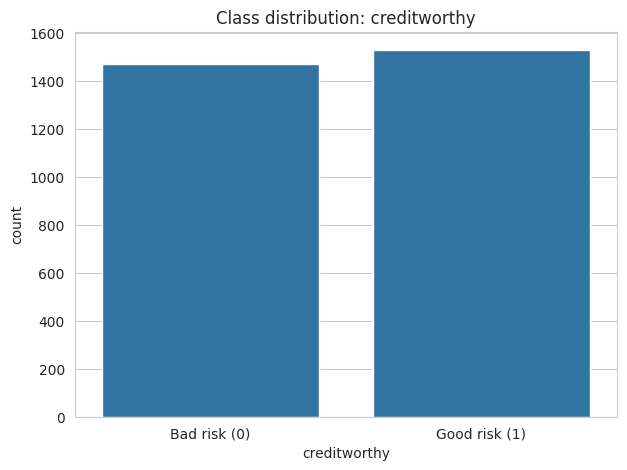

In [5]:
fig, ax = plt.subplots()
sns.countplot(data=df, x="creditworthy", ax=ax)
ax.set_xticklabels(["Bad risk (0)", "Good risk (1)"])
ax.set_title("Class distribution: creditworthy")
plt.show()

## 4. Exploratory Data Analysis

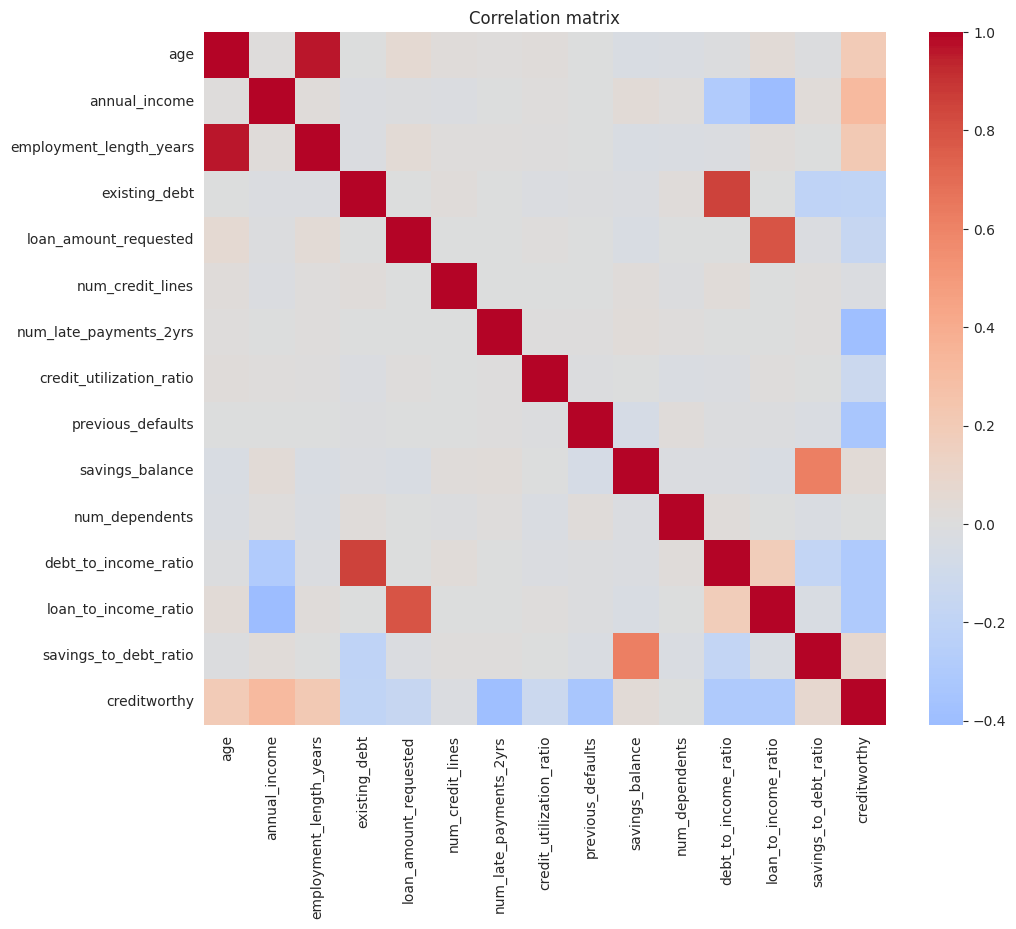

In [6]:
numeric_cols = [
    "age", "annual_income", "employment_length_years", "existing_debt",
    "loan_amount_requested", "num_credit_lines", "num_late_payments_2yrs",
    "credit_utilization_ratio", "previous_defaults", "savings_balance",
    "num_dependents", "debt_to_income_ratio", "loan_to_income_ratio",
    "savings_to_debt_ratio",
]

corr = df[numeric_cols + ["creditworthy"]].corr()
fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(corr, cmap="coolwarm", center=0, annot=False, ax=ax)
ax.set_title("Correlation matrix")
plt.show()

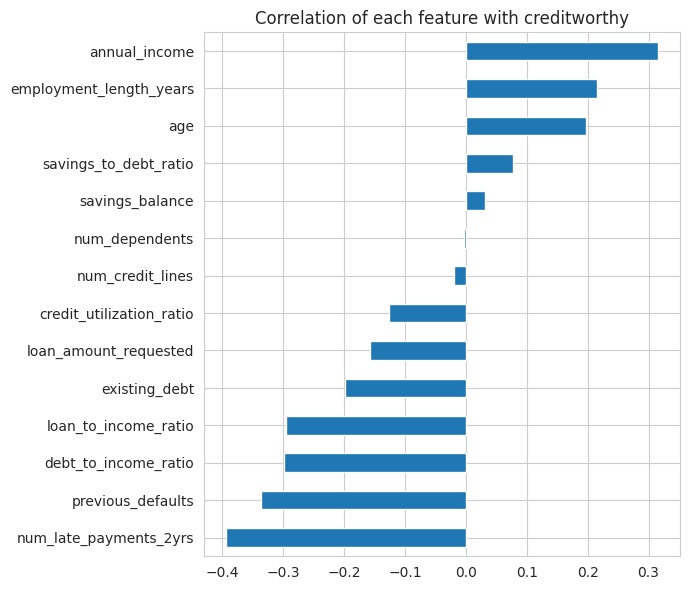

In [7]:
corr["creditworthy"].drop("creditworthy").sort_values().plot(
    kind="barh", figsize=(7, 6), title="Correlation of each feature with creditworthy"
)
plt.tight_layout()
plt.show()

## 5. Train / Test Split and Preprocessing

Numeric features are standardized (mainly for Logistic Regression) and categorical features (`home_ownership`, `loan_purpose`) are one-hot encoded. Everything is wrapped in a `ColumnTransformer` + `Pipeline` so each model gets identical, leakage-free preprocessing fit only on the training set.

In [8]:
categorical_cols = ["home_ownership", "loan_purpose"]

X = df.drop(columns=["creditworthy"])
y = df["creditworthy"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

preprocessor = ColumnTransformer(transformers=[
    ("num", StandardScaler(), numeric_cols),
    ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_cols),
])

print("Train shape:", X_train.shape, " Test shape:", X_test.shape)

Train shape: (2400, 16)  Test shape: (600, 16)


## 6. Model Training

Three classifiers are trained with identical preprocessing:

- Logistic Regression -- a linear baseline, easy to interpret via coefficients.
- Decision Tree -- captures non-linear splits, prone to overfitting if too deep.
- Random Forest -- an ensemble of trees, usually more robust than a single tree.

In [9]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(max_depth=6, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, max_depth=8, random_state=42),
}

fitted_pipelines = {}
predictions = {}
probabilities = {}

for name, clf in models.items():
    pipe = Pipeline([("prep", preprocessor), ("clf", clf)])
    pipe.fit(X_train, y_train)
    fitted_pipelines[name] = pipe
    predictions[name] = pipe.predict(X_test)
    probabilities[name] = pipe.predict_proba(X_test)[:, 1]

print("Models trained:", list(models.keys()))

Models trained: ['Logistic Regression', 'Decision Tree', 'Random Forest']


## 7. Model Evaluation

Metrics reported for each model: Accuracy, Precision, Recall, F1-Score, ROC-AUC. In a credit-scoring context Recall on the "bad risk" class and ROC-AUC usually matter more than raw accuracy, since misclassifying a bad-risk applicant as good is the costly error for a lender.

In [10]:
rows = []
for name in models:
    y_pred = predictions[name]
    y_proba = probabilities[name]
    rows.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_proba),
    })

results_df = pd.DataFrame(rows).set_index("Model").round(4)
results_df

,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Model,,,,,
Logistic Regression,0.8533,0.8609,0.8497,0.8553,0.9396
Decision Tree,0.7733,0.7656,0.8007,0.7827,0.8562
Random Forest,0.8283,0.8464,0.8105,0.8280,0.9170


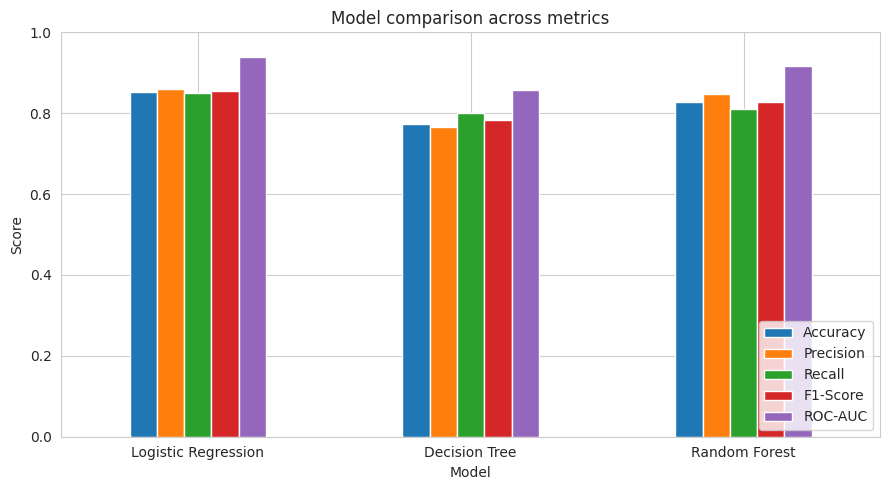

In [11]:
results_df.plot(kind="bar", figsize=(9, 5), ylim=(0, 1))
plt.title("Model comparison across metrics")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

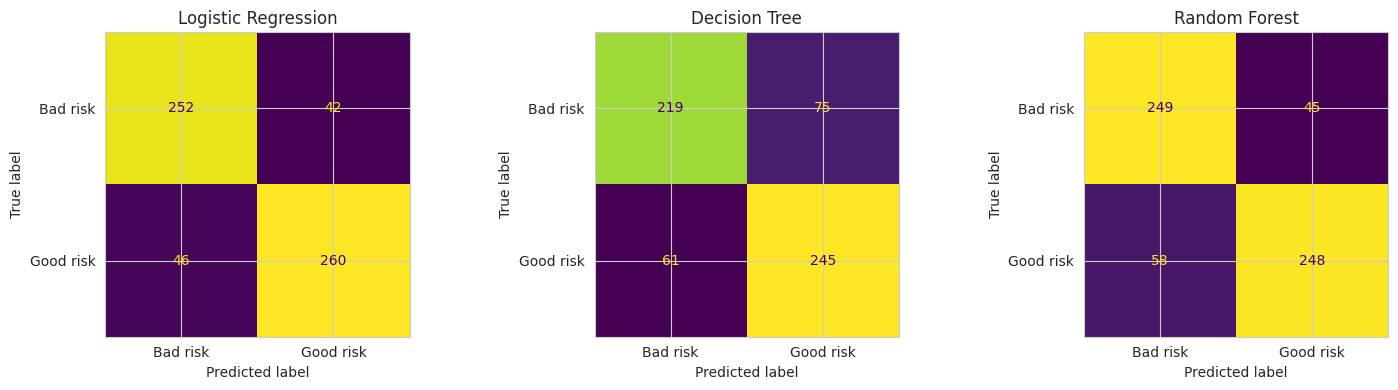

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, name in zip(axes, models):
    cm = confusion_matrix(y_test, predictions[name])
    ConfusionMatrixDisplay(cm, display_labels=["Bad risk", "Good risk"]).plot(
        ax=ax, colorbar=False
    )
    ax.set_title(name)
plt.tight_layout()
plt.show()

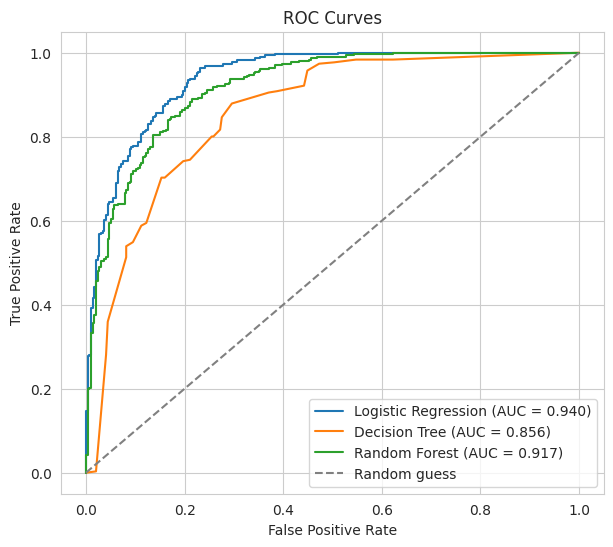

In [13]:
plt.figure(figsize=(7, 6))
for name in models:
    fpr, tpr, _ = roc_curve(y_test, probabilities[name])
    auc = roc_auc_score(y_test, probabilities[name])
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--", color="grey", label="Random guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend(loc="lower right")
plt.show()

In [14]:
for name in models:
    print(f"\n{'=' * 20} {name} {'=' * 20}")
    print(classification_report(y_test, predictions[name], target_names=["Bad risk", "Good risk"]))


==================== Logistic Regression ====================
              precision    recall  f1-score   support

    Bad risk       0.85      0.86      0.85       294
   Good risk       0.86      0.85      0.86       306

    accuracy                           0.85       600
   macro avg       0.85      0.85      0.85       600
weighted avg       0.85      0.85      0.85       600


==================== Decision Tree ====================
              precision    recall  f1-score   support

    Bad risk       0.78      0.74      0.76       294
   Good risk       0.77      0.80      0.78       306

    accuracy                           0.77       600
   macro avg       0.77      0.77      0.77       600
weighted avg       0.77      0.77      0.77       600


==================== Random Forest ====================
              precision    recall  f1-score   support

    Bad risk       0.81      0.85      0.83       294
   Good risk       0.85      0.81      0.83       306

    a

## 8. Feature Importance / Interpretability

Logistic Regression coefficients show direction and relative weight of each feature on log-odds of being a good credit risk. Random Forest importances show which features the ensemble relies on most.

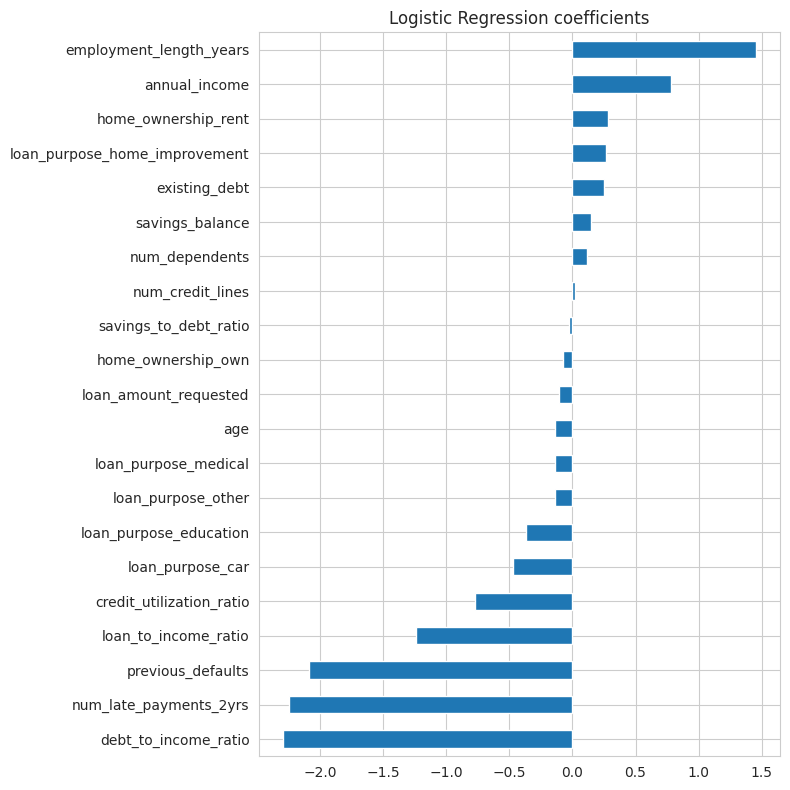

In [15]:
log_reg = fitted_pipelines["Logistic Regression"]
feature_names = numeric_cols + list(
    log_reg.named_steps["prep"].named_transformers_["cat"].get_feature_names_out(categorical_cols)
)
coefs = pd.Series(log_reg.named_steps["clf"].coef_[0], index=feature_names).sort_values()

coefs.plot(kind="barh", figsize=(8, 8), title="Logistic Regression coefficients")
plt.tight_layout()
plt.show()

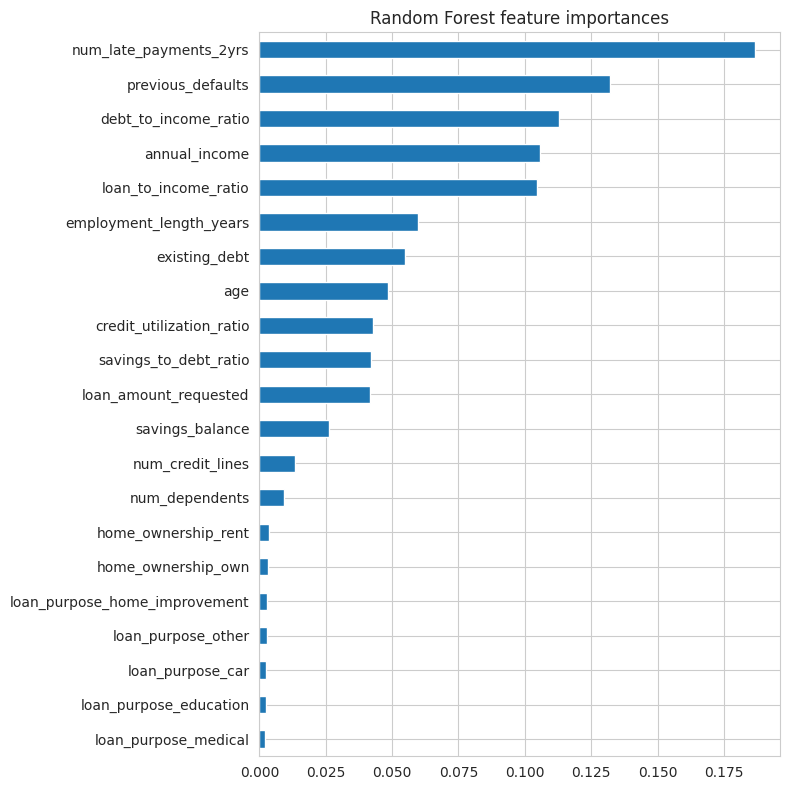

In [16]:
rf = fitted_pipelines["Random Forest"]
importances = pd.Series(
    rf.named_steps["clf"].feature_importances_, index=feature_names
).sort_values(ascending=False)

importances.plot(kind="barh", figsize=(8, 8), title="Random Forest feature importances")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## 9. Cross-Validation Check

A quick 5-fold cross-validation on ROC-AUC confirms the train/test split result is not a lucky split.

In [17]:
for name, clf in models.items():
    pipe = Pipeline([("prep", preprocessor), ("clf", clf)])
    scores = cross_val_score(pipe, X, y, cv=5, scoring="roc_auc")
    print(f"{name}: mean ROC-AUC = {scores.mean():.4f}  (std = {scores.std():.4f})")

Logistic Regression: mean ROC-AUC = 0.9494  (std = 0.0074)
Decision Tree: mean ROC-AUC = 0.8716  (std = 0.0203)


Random Forest: mean ROC-AUC = 0.9304  (std = 0.0145)


## 10. Conclusion

Summary of what the pipeline does:

1. Raw financial history (income, debt, payment behaviour, utilization, credit lines) is turned into model-ready features, including engineered ratios that mirror real underwriting logic (debt-to-income, loan-to-income, savings-to-debt).
2. Three classifiers are trained under identical preprocessing: Logistic Regression, Decision Tree, and Random Forest.
3. Models are compared on Accuracy, Precision, Recall, F1-Score, and ROC-AUC, plus confusion matrices and ROC curves.
4. Logistic Regression gave the strongest ROC-AUC here because the underlying risk score was built as a (mostly) linear combination of features -- in practice, the best model depends on the true relationship in real data, and Random Forest / Gradient Boosting typically outperform when interactions and non-linearities are present.
5. Feature importance analysis showed which factors drive the prediction most, which is important in credit scoring for regulatory explainability, not just raw predictive power.

To adapt this notebook to a real dataset (e.g. UCI German Credit Data, LendingClub, or a bank's internal data), only Section 2 needs to change: load the CSV/database table instead of generating synthetic data, and rename columns to match the pipeline's expected feature names.